In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df=sns.load_dataset("healthexp")

In [4]:
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [5]:
df.isnull().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

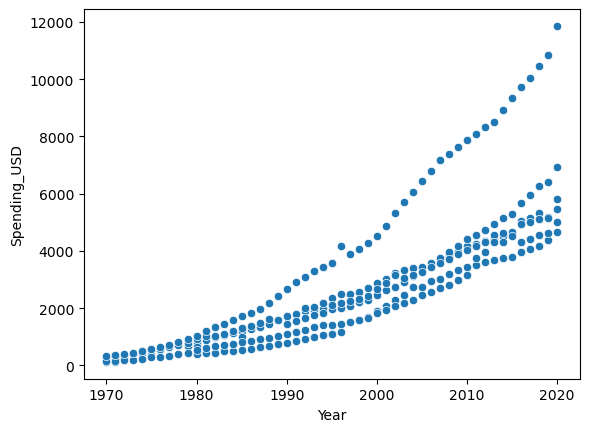

In [6]:
sns.scatterplot(data=df,x="Year",y="Spending_USD")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

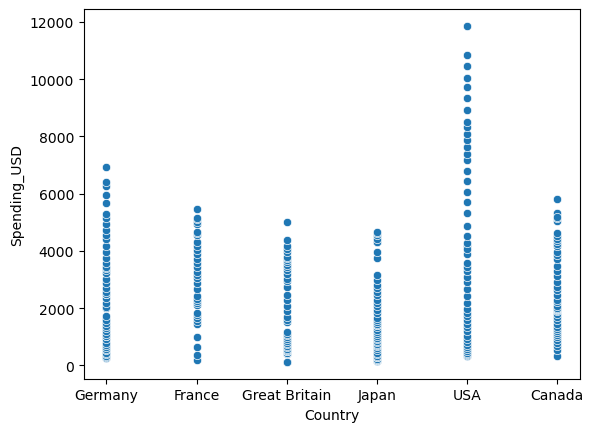

In [7]:
sns.scatterplot(data=df,x="Country",y="Spending_USD")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

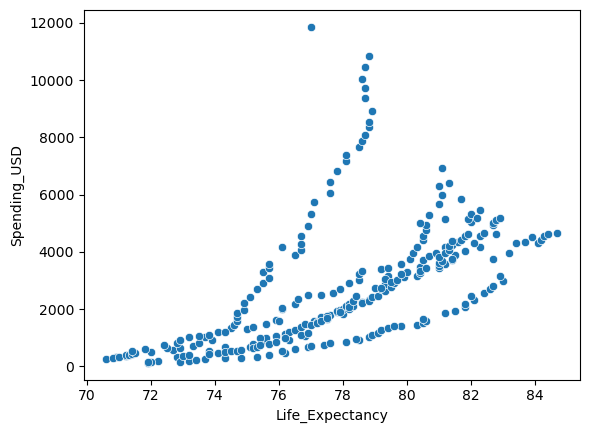

In [10]:
sns.scatterplot(data=df,x="Life_Expectancy",y="Spending_USD")
plt.show

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    object 
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.7+ KB


In [12]:
df.shape

(274, 4)

In [13]:
df.describe()

,Year,Spending_USD,Life_Expectancy
count,274.000000,274.000000,274.000000
mean,1996.992701,2789.338905,77.909489
std,14.180933,2194.939785,3.276263
min,1970.000000,123.993000,70.600000
25%,1985.250000,1038.357000,75.525000
50%,1998.000000,2295.578000,78.100000
75%,2009.000000,4055.610000,80.575000
max,2020.000000,11859.179000,84.700000


<Axes: xlabel='Spending_USD'>

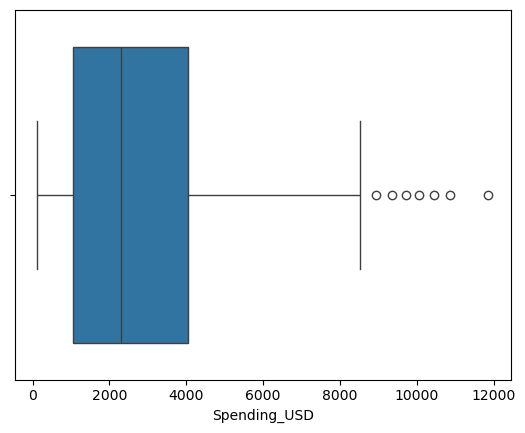

In [14]:
sns.boxplot(x="Spending_USD",data=df)

In [15]:
q1=df["Spending_USD"].quantile(0.25)
q3=df["Spending_USD"].quantile(0.75)
IQR=q3-q1
q3

np.float64(4055.61)

In [16]:
min_range=q1-(1.5*IQR)
max_range=q3+(1.5*IQR)
max_range,

(np.float64(8581.4895),)

In [17]:
clean_df=df[df["Spending_USD"]<=max_range]

<Axes: xlabel='Spending_USD'>

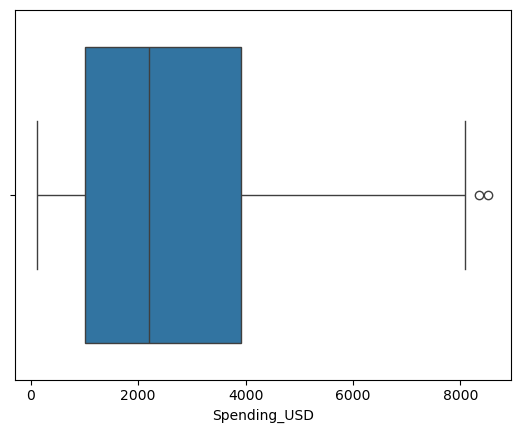

In [18]:
sns.boxplot(x="Spending_USD",data=clean_df)

In [19]:
clean_df.describe()

,Year,Spending_USD,Life_Expectancy
count,267.000000,267.000000,267.000000
mean,1996.468165,2595.759026,77.894382
std,13.981255,1857.495574,3.316252
min,1970.000000,123.993000,70.600000
25%,1985.000000,1017.980000,75.500000
50%,1997.000000,2200.468000,78.100000
75%,2008.000000,3920.077500,80.600000
max,2020.000000,8519.620000,84.700000


<Axes: xlabel='Year', ylabel='Spending_USD'>

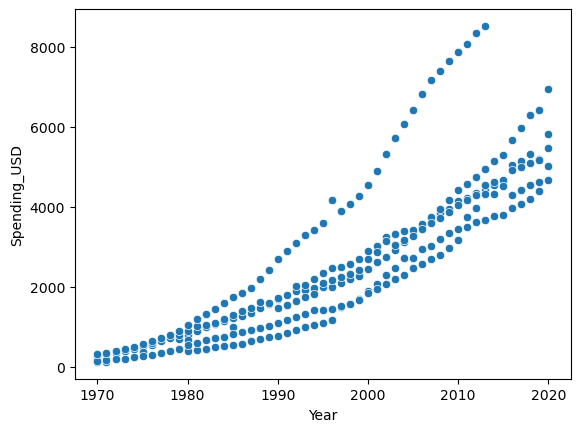

In [20]:
sns.scatterplot(data=clean_df,x="Year",y="Spending_USD")

In [21]:
clean_df.head(6)

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8


In [22]:
clean_df.duplicated().sum()

np.int64(0)

In [23]:
clean_df["Country"].unique()

array(['Germany', 'France', 'Great Britain', 'Japan', 'USA', 'Canada'],
      dtype=object)

In [24]:
oe=OrdinalEncoder()

In [27]:
clean_df[["country_edc"]]=oe.fit_transform(clean_df[["Country"]])

C:\Users\SALMAN PC\AppData\Local\Temp\ipykernel_2436\339134266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df[["country_edc"]]=oe.fit_transform(clean_df[["Country"]])


In [28]:
clean_df.head()

,Year,Country,Spending_USD,Life_Expectancy,country_edc
0,1970,Germany,252.311,70.6,2.0
1,1970,France,192.143,72.2,1.0
2,1970,Great Britain,123.993,71.9,3.0
3,1970,Japan,150.437,72.0,4.0
4,1970,USA,326.961,70.9,5.0


In [29]:
clean_df=clean_df.drop("Country",axis=1)

In [30]:
clean_df.head()

,Year,Spending_USD,Life_Expectancy,country_edc
0,1970,252.311,70.6,2.0
1,1970,192.143,72.2,1.0
2,1970,123.993,71.9,3.0
3,1970,150.437,72.0,4.0
4,1970,326.961,70.9,5.0


In [33]:
x=clean_df.drop("Life_Expectancy",axis=1)
y=clean_df["Life_Expectancy"]

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [42]:
# model=LinearRegression
from sklearn.linear_model import LinearRegression

model = LinearRegression()   # ✅ correct

In [43]:
model.fit(x_train,y_train)

LinearRegression()

In [41]:
print(type(model))

<class 'abc.ABCMeta'>


In [45]:
prid_y=model.predict(x_test)
prid_y

array([76.45149836, 74.87475922, 77.4906321 , 81.96977169, 77.47993971,
       81.31528979, 75.84523184, 83.44113665, 77.50107456, 76.57110465,
       80.86891817, 78.26069209, 82.71694896, 78.48176475, 79.89651382,
       77.0549983 , 79.28616306, 78.65168382, 81.9416708 , 72.0195652 ,
       73.30440936, 74.99374256, 77.72676022, 77.73583077, 80.80847914,
       73.80627485, 81.38063277, 76.38298907, 77.89051976, 81.64825459,
       72.00610594, 75.95935648, 77.53135556, 75.41166181, 81.6919553 ,
       79.56736684, 77.96505435, 73.04478784, 79.70054873, 77.70719291,
       78.22570922, 79.12120962, 80.13743812, 82.50435114, 72.5683563 ,
       76.12996839, 82.68659394, 77.47749909, 74.10297336, 79.29078544,
       76.72915439, 81.50100414, 72.80253977, 72.2817716 ])

In [47]:
print(mean_squared_error(y_test, prid_y))
r2_score(y_test, prid_y)

1.396525925595371


0.8900578724087259

In [48]:
train_r2 = model.score(x_train, y_train)
test_r2 = model.score(x_test, y_test)

In [49]:
train_r2,test_r2

(0.9031764436754308, 0.8900578724087259)